# Exploratory Data Analysis: Daily Ridership Patterns

This notebook reads the cleaned trip-level dataset from `01_Data_Cleaning`, aggregates it to a **daily time series**, and explores the temporal patterns that will drive our demand forecasting models.

Key questions:
1. What does the overall daily ridership trend look like across 2023?
2. What weekly and seasonal patterns exist?
3. Is the series stationary? What lag structure does the data exhibit?
4. How do weekday/weekend and holiday effects manifest?
5. How does trip duration co-vary with demand volume?

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

sns.set_theme(style="whitegrid")

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "ridership_2023_clean.csv"
df = pd.read_csv(DATA_PATH)
print(f"{len(df):,} trips loaded")

5,344,361 trips loaded


### Aggregate to Daily Time Series

We use `src/timeseries.aggregate_daily` to collapse ~5.3M trips into 365 daily observations. This is our forecasting target: daily trip count.

In [3]:
from src.timeseries import aggregate_daily

daily = aggregate_daily(df)
print(f"{len(daily)} days and {daily['trip_count'].sum():,} total trips")
print(f"Date range: {daily.index.min().date()} to {daily.index.max().date()}")
daily.head(10)

365 days and 5,344,361 total trips
Date range: 2023-01-01 to 2023-12-31


,trip_count,mean_duration_min,median_duration_min,pct_annual_member,pct_peak_hour,pct_weekend
date,,,,,,
2023-01-01,3666,13.483383,11.750000,0.253682,0.340153,1.0
2023-01-02,5457,11.920753,9.900000,0.293751,0.497160,0.0
2023-01-03,5326,11.606281,9.825000,0.296846,0.596132,0.0
2023-01-04,3467,11.171695,9.333333,0.318142,0.508509,0.0
2023-01-05,6267,11.713834,9.933333,0.306207,0.579703,0.0
2023-01-06,7148,11.621314,9.850000,0.302322,0.543229,0.0
2023-01-07,6246,11.975523,10.000000,0.290266,0.444605,1.0
2023-01-08,5090,11.364145,9.333333,0.272102,0.443615,1.0
2023-01-09,6927,11.101521,9.316667,0.294933,0.619749,0.0


In [ ]:
# Descriptive statistics for daily trip counts
desc = daily['trip_count'].describe()
print(f"Mean: {desc['mean']:,.0f} trips/day")
print(f"Median: {desc['50%']:,.0f} trips/day")
print(f"Std: {desc['std']:,.0f}")
print(f"Min: {desc['min']:,.0f} ({daily['trip_count'].idxmin().date()})")
print(f"Max: {desc['max']:,.0f} ({daily['trip_count'].idxmax().date()})")

Mean: 14,642 trips/day
Median: 14,976 trips/day
Std: 7,188
Min: 1,238 (2023-02-23)
Max:  25,940 (2023-07-19)


### Daily Ridership Trend

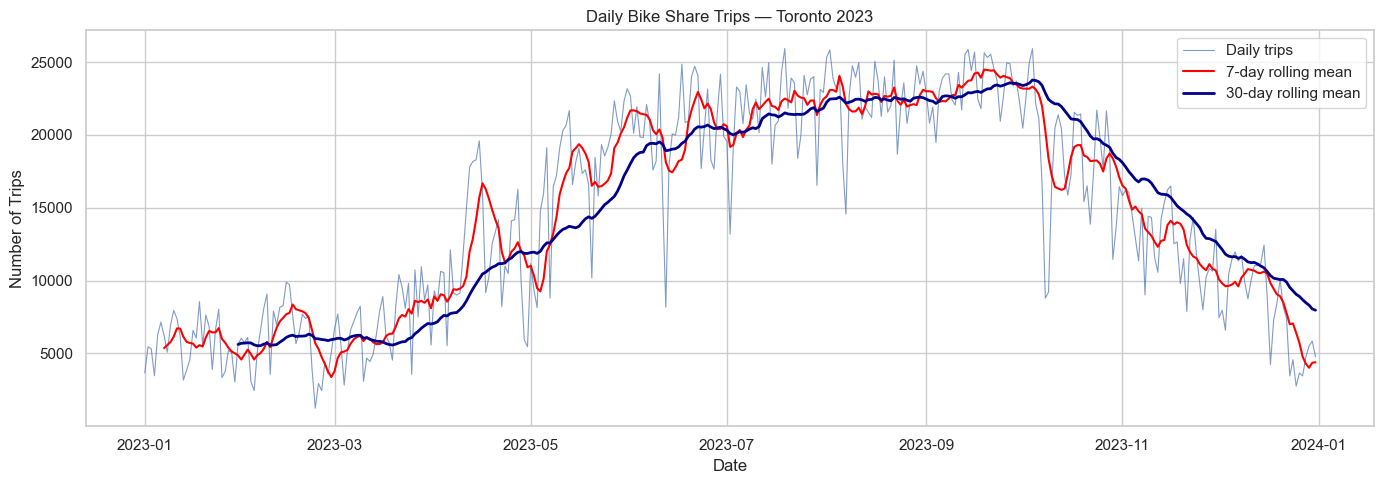

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily.index, daily['trip_count'], linewidth=0.8, alpha=0.7, label='Daily trips')

# 7-day rolling mean
rolling7 = daily['trip_count'].rolling(7).mean()
ax.plot(daily.index, rolling7, color='red', linewidth=1.5, label='7-day rolling mean')

# 30-day rolling mean
rolling30 = daily['trip_count'].rolling(30).mean()
ax.plot(daily.index, rolling30, color='darkblue', linewidth=2, label='30-day rolling mean')

ax.set_title('Daily Bike Share Trips — Toronto 2023')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Trips')
ax.legend()
plt.tight_layout()
plt.show()

### Seasonal Decomposition

We decompose the daily series into trend, seasonal (weekly, period=7), and residual components using an additive model.

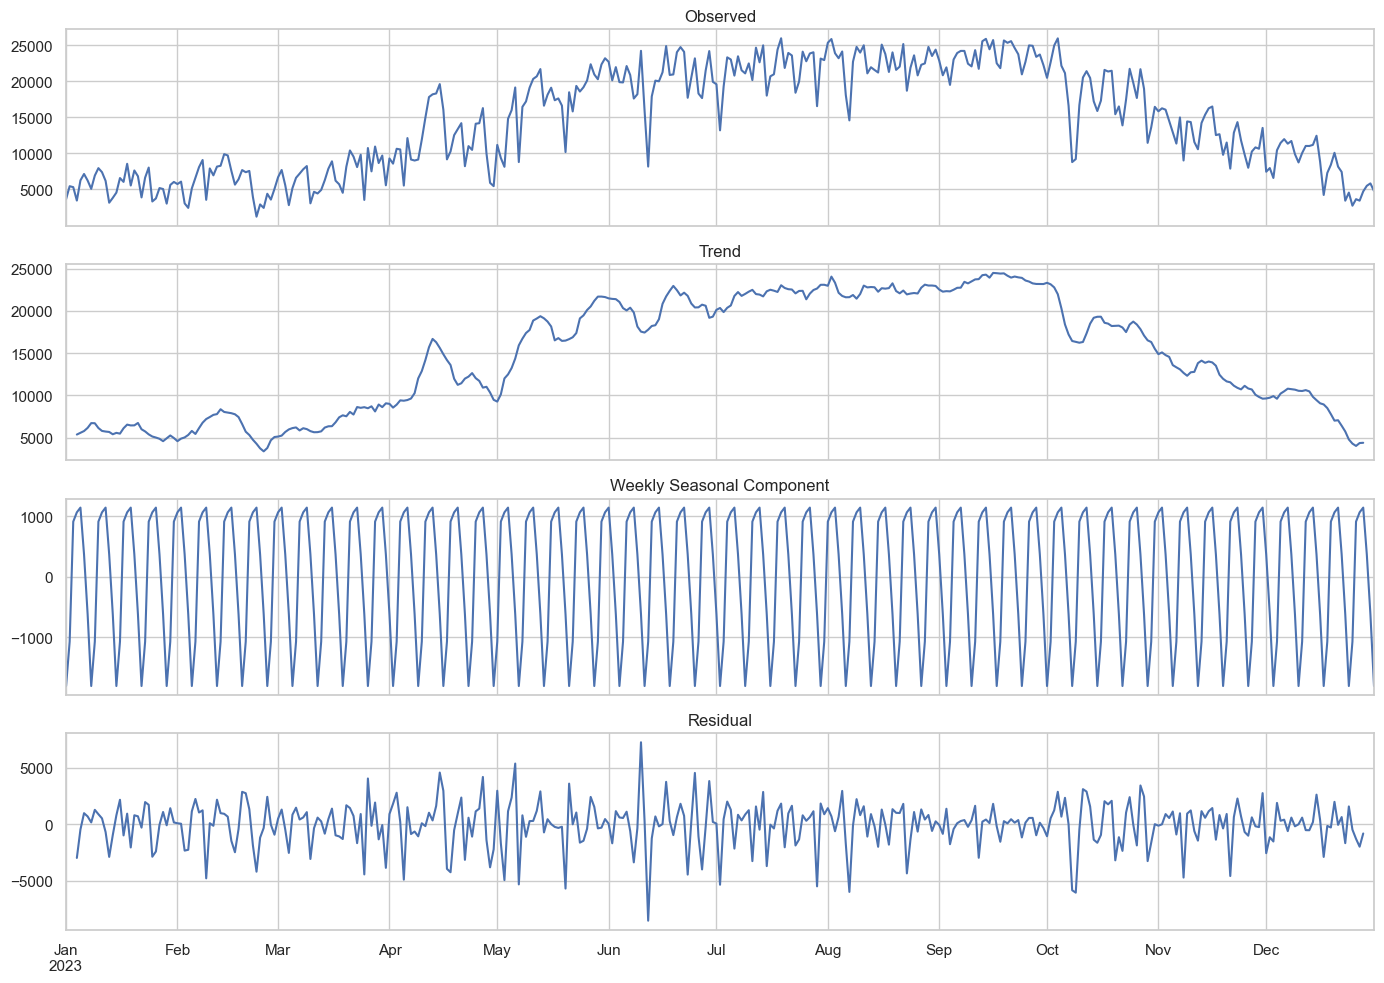

In [6]:
decomp = seasonal_decompose(daily['trip_count'], model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp.observed.plot(ax=axes[0], title='Observed')
decomp.trend.plot(ax=axes[1], title='Trend')
decomp.seasonal.plot(ax=axes[2], title='Weekly Seasonal Component')
decomp.resid.plot(ax=axes[3], title='Residual')

for ax in axes:
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

### Day-of-Week Patterns

        mean   median     std
Mon  13616.0  11704.0  6386.0
Tue  15556.0  15900.0  7003.0
Wed  15727.0  16797.0  7526.0
Thu  15808.0  17042.0  7181.0
Fri  15040.0  16018.0  7411.0
Sat  14072.0  15501.0  7639.0
Sun  12713.0  11006.0  6904.0


/var/folders/dv/8f4r5dp50yv_lywv_s27_ncw0000gn/T/ipykernel_61991/143934088.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(day_names)


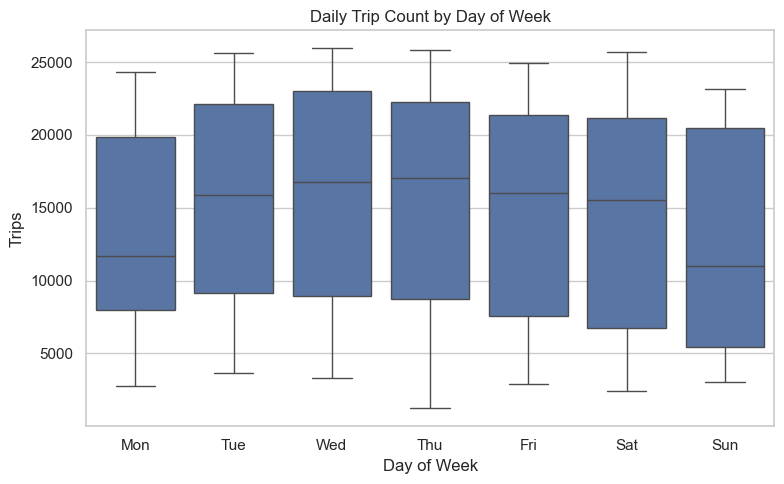

In [7]:
daily['day_of_week'] = daily.index.dayofweek
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

dow_stats = daily.groupby('day_of_week')['trip_count'].agg(['mean', 'median', 'std']).round(0)
dow_stats.index = day_names
print(dow_stats)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=daily, x='day_of_week', y='trip_count', ax=ax)
ax.set_xticklabels(day_names)
ax.set_title('Daily Trip Count by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Trips')
plt.tight_layout()
plt.show()

### Monthly Patterns

        mean   median     sum
Jan   5633.0   5625.0  174609
Feb   5958.0   6252.0  166828
Mar   7010.0   7198.0  217318
Apr  11865.0  10822.0  355947
May  17380.0  18461.0  538773
Jun  20428.0  20666.0  612846
Jul  21765.0  22608.0  674715
Aug  22647.0  23176.0  702068
Sep  23470.0  23708.0  704100
Oct  18389.0  18936.0  570046
Nov  12685.0  12760.0  380553
Dec   7953.0   8165.0  246558


/var/folders/dv/8f4r5dp50yv_lywv_s27_ncw0000gn/T/ipykernel_61991/480582959.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(month_names)


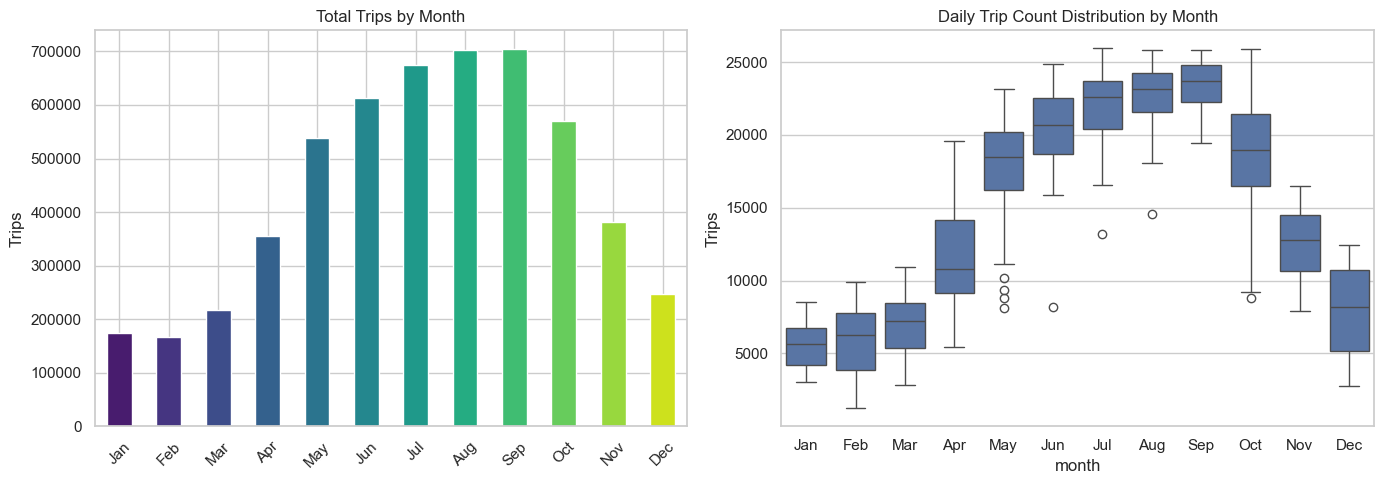

In [8]:
daily['month'] = daily.index.month
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

monthly_stats = daily.groupby('month')['trip_count'].agg(['mean', 'median', 'sum']).round(0)
monthly_stats.index = month_names
print(monthly_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total trips per month
monthly_stats['sum'].plot(kind='bar', ax=axes[0], color=sns.color_palette('viridis', 12))
axes[0].set_title('Total Trips by Month')
axes[0].set_ylabel('Trips')
axes[0].tick_params(axis='x', rotation=45)

# Box plot of daily counts by month
sns.boxplot(data=daily, x='month', y='trip_count', ax=axes[1])
axes[1].set_xticklabels(month_names)
axes[1].set_title('Daily Trip Count Distribution by Month')
axes[1].set_ylabel('Trips')

plt.tight_layout()
plt.show()

### Stationarity Testing

A stationary series has constant mean and variance over time. We run the Augmented Dickey-Fuller test on the raw daily counts and on the first-differenced series to understand the trend structure and inform whether differencing or detrending is needed for modeling.

In [14]:
def adf_report(series, label):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"{label}")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.6f}")
    print(f"Lags used: {result[2]}")
    for k, v in result[4].items():
        print(f"Critical ({k}): {v:.4f}")
    verdict = 'Stationary' if result[1] < 0.05 else 'Non-stationary'
    print(f"to {verdict} (at 5% significance)\n")

adf_report(daily['trip_count'], 'Raw daily trip count')
adf_report(daily['trip_count'].diff(), 'First-differenced trip count')

Raw daily trip count
ADF Statistic: -1.0722
p-value: 0.726039
Lags used: 15
Critical (1%): -3.4492
Critical (5%): -2.8699
Critical (10%): -2.5712
to Non-stationary (at 5% significance)

First-differenced trip count
ADF Statistic: -5.7729
p-value: 0.000001
Lags used: 14
Critical (1%): -3.4492
Critical (5%): -2.8699
Critical (10%): -2.5712
to Stationary (at 5% significance)



### ACF & PACF

Autocorrelation (ACF) and partial autocorrelation (PACF) plots reveal the lag structure in the data. Significant spikes tell us which past days are most predictive of today. This directly informs which lag features to engineer for the models.

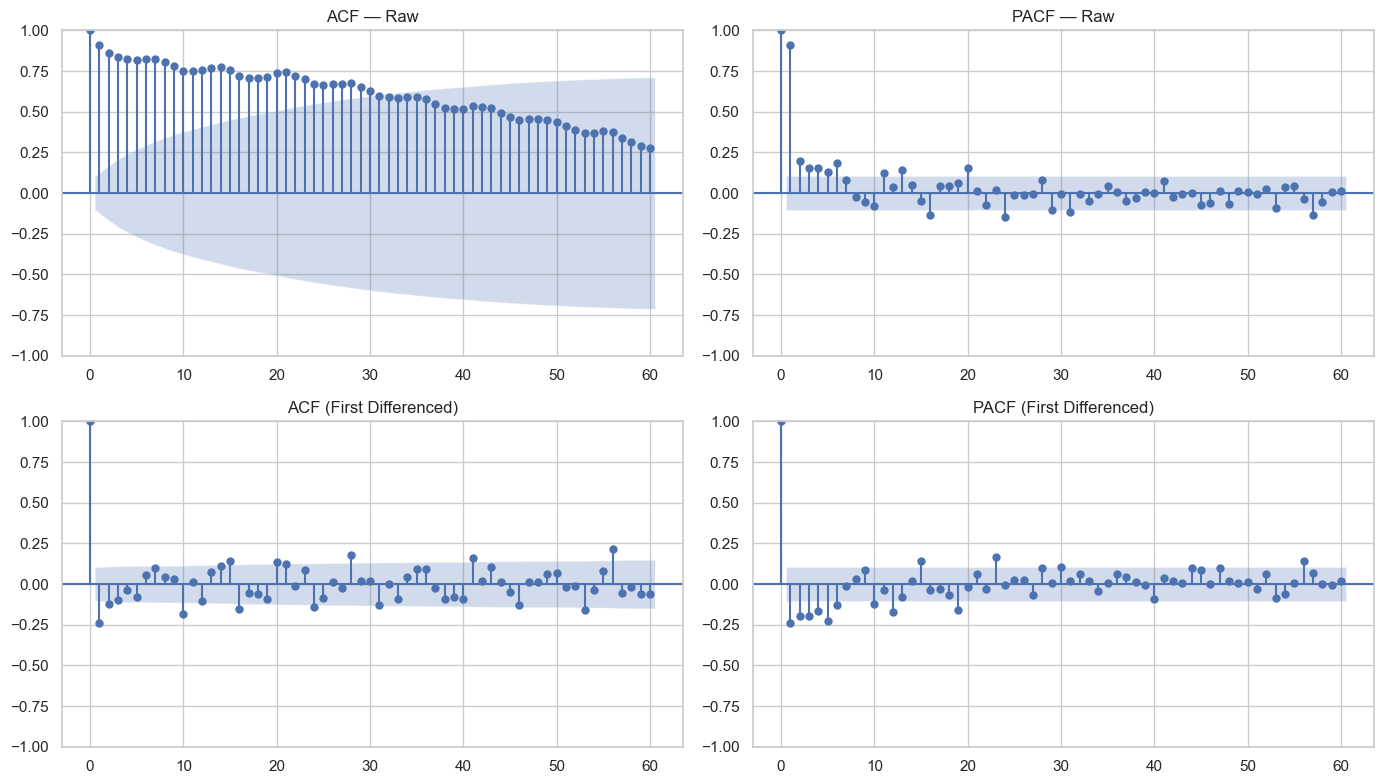

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(daily['trip_count'].dropna(), lags=60, ax=axes[0, 0], title='ACF — Raw')
plot_pacf(daily['trip_count'].dropna(), lags=60, ax=axes[0, 1], title='PACF — Raw')

diff1 = daily['trip_count'].diff().dropna()
plot_acf(diff1, lags=60, ax=axes[1, 0], title='ACF (First Differenced)')
plot_pacf(diff1, lags=60, ax=axes[1, 1], title='PACF (First Differenced)')

plt.tight_layout()
plt.show()

### Weekend and Holiday

             mean   median  count
day_type                         
Holiday    9616.0   8272.0     10
Weekday   15341.0  16239.0    252
Weekend   13420.0  12654.0    103


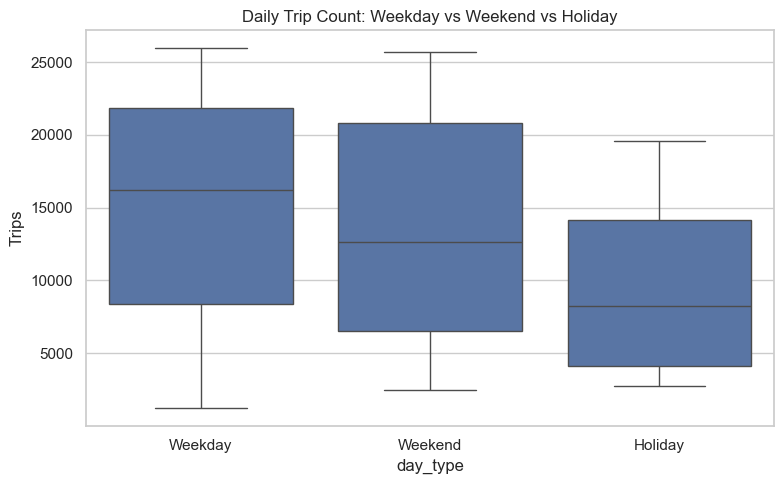

In [ ]:
try:
    import holidays
    canadian_holidays = holidays.Canada(prov='ON', years=2023)
    daily['is_holiday'] = daily.index.map(lambda d: int(d in canadian_holidays))
except ImportError:
    print('holidays library not installed — skipping holiday flag')
    daily['is_holiday'] = 0

daily['is_weekend'] = (daily['day_of_week'] >= 5).astype(int)

# Create a combined category for comparison
conditions = [daily['is_holiday'] == 1, daily['is_weekend'] == 1,]
labels = ['Holiday', 'Weekend']
daily['day_type'] = np.select(conditions, labels, default='Weekday')

day_type_stats = daily.groupby('day_type')['trip_count'].agg(['mean', 'median', 'count']).round(0)
print(day_type_stats)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=daily, x='day_type', y='trip_count', order=['Weekday', 'Weekend', 'Holiday'], ax=ax)
ax.set_title('Daily Trip Count: Weekday vs Weekend vs Holiday')
ax.set_ylabel('Trips')
plt.tight_layout()
plt.show()

### Trip Duration vs. Demand Volume

Do high-demand days tend to have shorter or longer average trips?

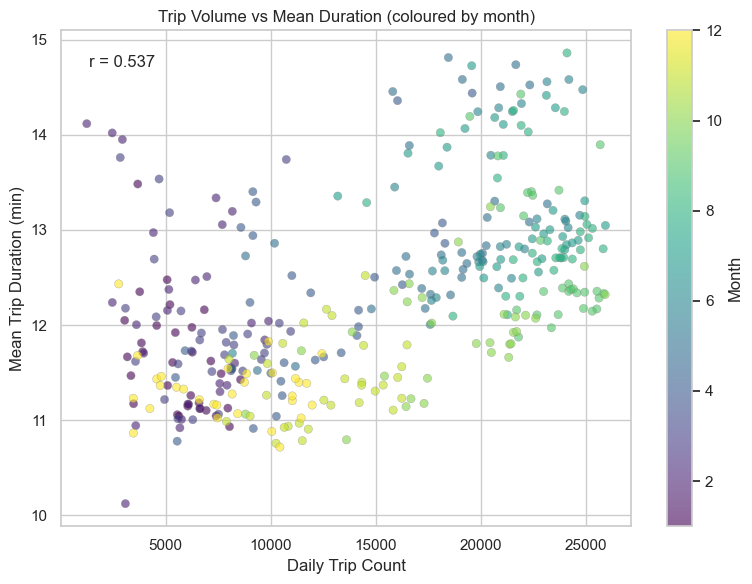

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    daily['trip_count'],
    daily['mean_duration_min'],
    c=daily['month'],
    cmap='viridis',
    alpha=0.6,
    edgecolors='grey',
    linewidth=0.3,
)
plt.colorbar(sc, label='Month')
ax.set_xlabel('Daily Trip Count')
ax.set_ylabel('Mean Trip Duration (min)')
ax.set_title('Trip Volume vs Mean Duration (coloured by month)')

r = daily[['trip_count', 'mean_duration_min']].corr().iloc[0, 1]
ax.annotate(f'r = {r:.3f}', 
            xy=(0.05, 0.95),
            xycoords='axes fraction',
            fontsize=12, ha='left',
            va='top',
            bbox=dict(boxstyle='round', fc='white',alpha=0.8)
)

plt.tight_layout()
plt.show()

### Summary of Findings

Key observations for modeling:

- **Strong seasonality:** ridership peaks in summer (Jun–Sep) and drops sharply in winter. Monthly features (cyclical sin/cos) will help models capture this.
- **Weekly cycle:** clear weekday > weekend pattern, with Friday typically highest. A 7-day lag feature should be highly predictive.
- **Holiday dips:** Ontario statutory holidays show reduced ridership, justifying a binary holiday flag.
- **ACF/PACF:** strong autocorrelation at lags 1 and 7 confirms that yesterday's count and same-day-last-week are the best single predictors. Rolling means will capture the broader seasonal trend.
- **Duration correlation:** mean trip duration and volume move together, likely driven by weather (warm → more + longer rides).

These findings directly inform the feature engineering in the third notebook and the model specifications in the fourth.